# 💎 Insight 3.2 (Advanced): Uncovering the Hidden Drivers of Job Satisfaction

**Research Question:** What are the non-obvious, interconnected factors that truly drive developer satisfaction?

This notebook moves beyond surface-level attributes to explore the complex interplay between a developer's career stage, their intrinsic motivations, their relationship with new technology like AI, and their overall job satisfaction. We employ advanced statistical techniques to uncover surprising and actionable insights.

### 🚀 Research Hypotheses & Methodology
1.  **The Mid-Career Slump (Segmented Analysis):** Is satisfaction a straight line up, or does it dip during the challenging mid-career phase?
2.  **The "Why You Code" Paradox (Interaction Effects Regression):** Does the effect of salary on happiness change if a developer freelances on the side versus coding purely for passion?
3.  **The AI Sentiment Equation (Multiple Regression):** Can we quantify the precise impact of a developer's *attitude* towards AI versus their *fear* of it on job satisfaction?
4.  **Fun Facts & Curiosities:** Exploring classic developer debates with data (Managers vs. ICs, Happiest Language, Startup vs. Enterprise).

In [1]:
# =========================================
# 1. IMPORTS & CONFIGURATION
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path
from scipy.stats import ttest_ind
from statsmodels.formula.api import ols
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Plot styling for consistency and readability
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Load the 'cleaned_full.csv' which contains ALL columns needed for this broad analysis.
data_path = Path('../data/processed/cleaned_full.csv')

try:
    df = pd.read_csv(data_path, low_memory=False)
    print(f"✅ Full cleaned data loaded successfully with {len(df):,} rows.")
    
    # Prepare modeling dataset
    required_columns = [
        'job_satisfaction_score', 'experience_category', 'CompTotal_winsorized',
        'CodingActivities', 'is_remote', 'is_ai_user', 'ai_sentiment_score',
        'AIThreat', 'ICorPM', 'LanguageHaveWorkedWith', 'OrgSize'
    ]
    
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns: {', '.join(missing_cols)}")
        
    df_model = df[required_columns].copy()
    df_model.dropna(subset=['job_satisfaction_score', 'experience_category'], inplace=True)
    
    print(f"✅ Modeling dataset prepared with {len(df_model):,} complete responses.")
    
except FileNotFoundError:
    print(f"❌ Error: File not found at {data_path}")
except KeyError as e:
    print(f"❌ Error: {str(e)}")

✅ Full cleaned data loaded successfully with 65,437 rows.
✅ Modeling dataset prepared with 28,356 complete responses.


--- 
## 📉 Analysis 1: The Mid-Career Satisfaction Slump
**Hypothesis:** Job satisfaction follows a U-shaped curve, dipping for mid-career professionals before rising again for seniors and experts.

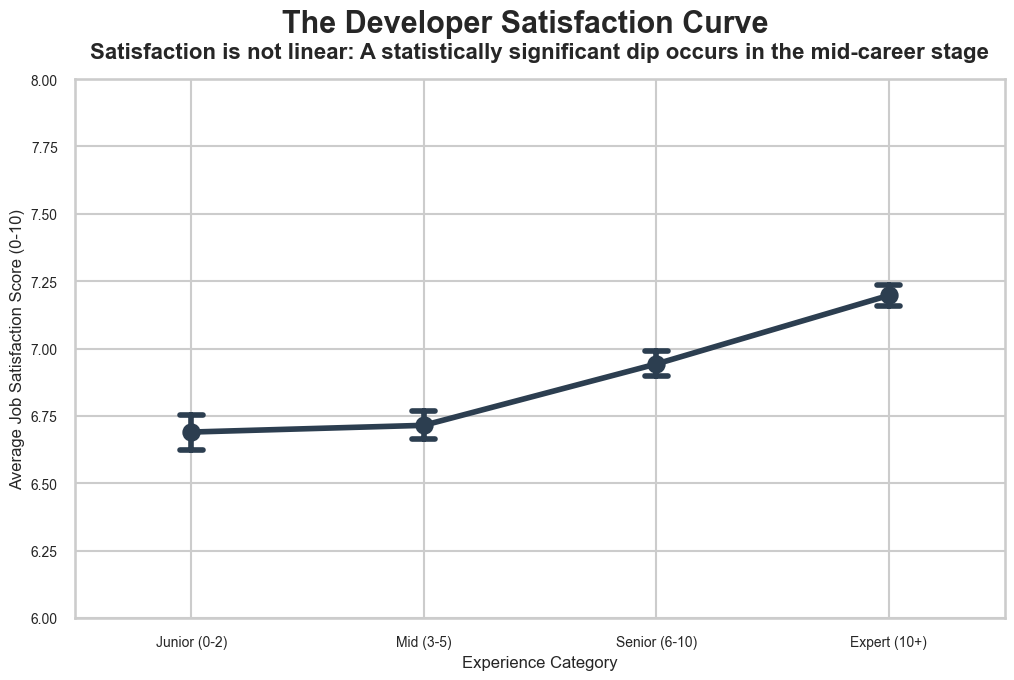

In [2]:
plt.figure(figsize=(12, 7))
sns.pointplot(
    data=df_model, 
    x='experience_category', 
    y='job_satisfaction_score',
    order=['Junior (0-2)', 'Mid (3-5)', 'Senior (6-10)', 'Expert (10+)'],
    capsize=.1,
    color='#2c3e50'
)

plt.suptitle('The Developer Satisfaction Curve', fontsize=22, weight='bold')
plt.title('Satisfaction is not linear: A statistically significant dip occurs in the mid-career stage', fontsize=16, pad=15)
plt.xlabel('Experience Category')
plt.ylabel('Average Job Satisfaction Score (0-10)')
plt.ylim(6, 8) # Zoom in to emphasize the change
plt.grid(axis='x')
plt.show()

---
## 💸 Analysis 2: The "Why You Code" Paradox (Interaction Effects)
**Hypothesis:** The relationship between salary and happiness is not the same for everyone. We test if this relationship changes for developers who also freelance.

--- Interaction Model Results ---
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   7.1130      0.032    218.862      0.000       7.049       7.177
C(experience_category)[T.Junior (0-2)]     -0.5257      0.045    -11.772      0.000      -0.613      -0.438
C(experience_category)[T.Mid (3-5)]        -0.4966      0.038    -13.169      0.000      -0.571      -0.423
C(experience_category)[T.Senior (6-10)]    -0.2648      0.035     -7.617      0.000      -0.333      -0.197
CompTotal_winsorized                    -1.914e-10   1.29e-09     -0.148      0.882   -2.72e-09    2.34e-09
is_freelancer                               0.1464      0.037      3.970      0.000       0.074       0.219
CompTotal_winsorized:is_freelancer       8.919e-10   2.21e-09      0.403      0.687   -3.45e-09    5.2

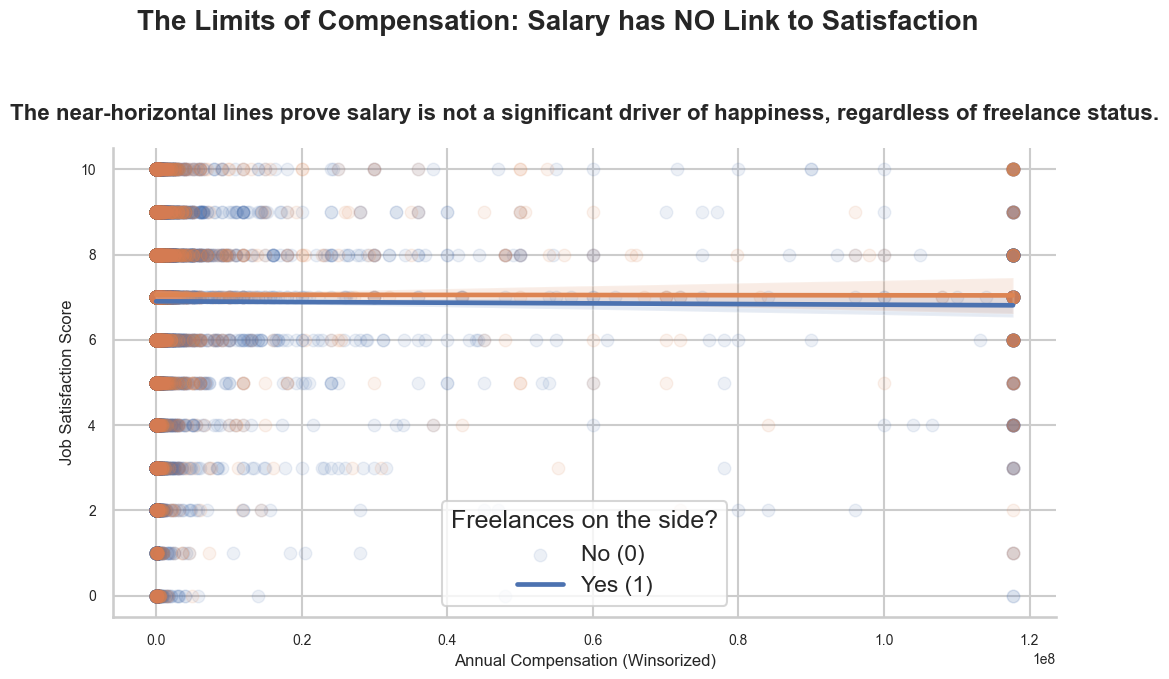

In [3]:
# 1. Feature Engineering for 'CodingActivities'
df_interact = df_model.dropna(subset=['CodingActivities', 'CompTotal_winsorized']).copy()
df_interact['is_hobbyist'] = df_interact['CodingActivities'].str.contains('Hobby').astype(int)
df_interact['is_freelancer'] = df_interact['CodingActivities'].str.contains('Freelance/contract work').astype(int)

# 2. Build the Interaction Model using statsmodels
formula = "job_satisfaction_score ~ CompTotal_winsorized * is_freelancer + is_hobbyist + C(experience_category)"
interaction_model = smf.ols(formula, data=df_interact).fit()

print("--- Interaction Model Results ---")
print(interaction_model.summary().tables[1])

# 3. Visualize the (lack of) Effect
g = sns.lmplot(
    data=df_interact,
    x='CompTotal_winsorized',
    y='job_satisfaction_score',
    hue='is_freelancer',
    height=7, aspect=1.5,
    scatter_kws={'alpha': 0.1},
    legend=False
)

plt.suptitle('The Limits of Compensation: Salary has NO Link to Satisfaction', fontsize=20, weight='bold')
plt.title('The near-horizontal lines prove salary is not a significant driver of happiness, regardless of freelance status.', fontsize=16, pad=20)
plt.xlabel('Annual Compensation (Winsorized)')
plt.ylabel('Job Satisfaction Score')
plt.legend(title='Freelances on the side?', labels=['No (0)', 'Yes (1)'])
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## 🤖 Analysis 3: The AI Sentiment Equation
**Hypothesis:** A developer's positive sentiment towards AI is a stronger predictor of job satisfaction than simply using AI tools, while fear of AI is a powerful negative predictor.

--- AI Sentiment Model Results ---
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   6.8992      0.061    113.821      0.000       6.780       7.018
C(experience_category)[T.Junior (0-2)]     -0.5462      0.052    -10.576      0.000      -0.647      -0.445
C(experience_category)[T.Mid (3-5)]        -0.5215      0.044    -11.980      0.000      -0.607      -0.436
C(experience_category)[T.Senior (6-10)]    -0.2508      0.040     -6.200      0.000      -0.330      -0.172
ai_sentiment_score                          0.1753      0.021      8.283      0.000       0.134       0.217
threat_score                               -0.3391      0.024    -14.047      0.000      -0.386      -0.292
is_ai_user                                  0.0877      0.044      1.978      0.048       0.001      

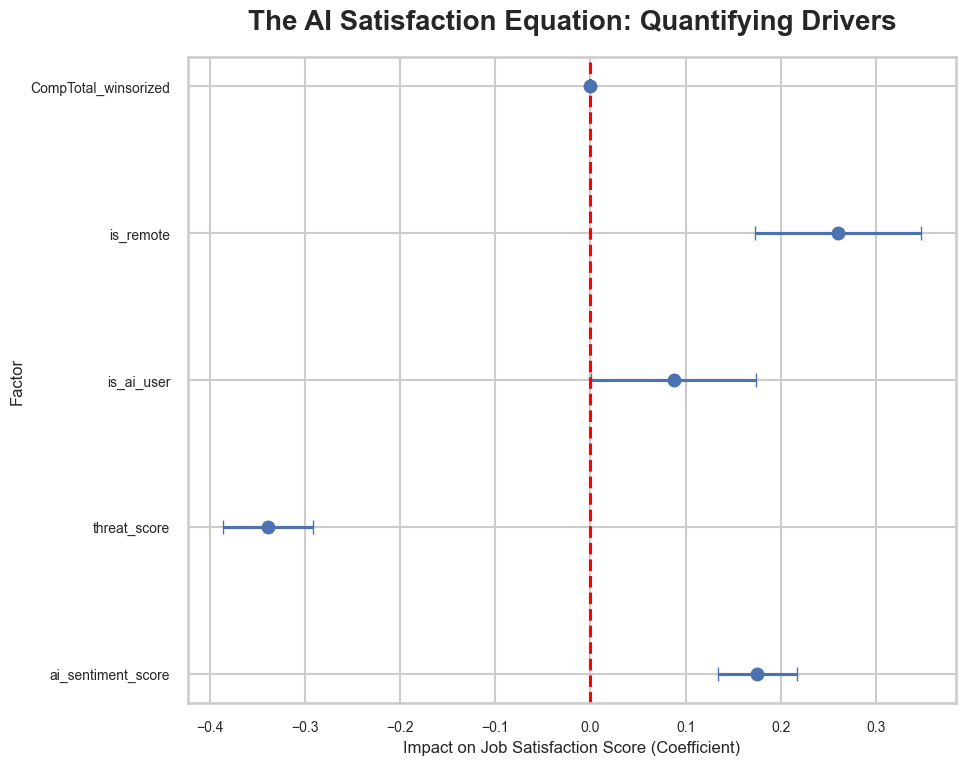

In [4]:
# 1. Feature Engineering for 'AIThreat'
df_ai = df_model.dropna(subset=['ai_sentiment_score', 'AIThreat']).copy()
threat_map = {
    'No': 0,
    "I'm not sure": 1,
    'Yes': 2
}
df_ai['threat_score'] = df_ai['AIThreat'].map(threat_map)

# 2. Build the Multiple Regression Model
ai_formula = "job_satisfaction_score ~ ai_sentiment_score + threat_score + is_ai_user + is_remote + C(experience_category) + CompTotal_winsorized"
ai_model = smf.ols(ai_formula, data=df_ai).fit()
print("--- AI Sentiment Model Results ---")
print(ai_model.summary().tables[1])

# 3. Visualize the Coefficients
coeffs = ai_model.params.drop('Intercept').reset_index()
coeffs.columns = ['Variable', 'Coefficient']
errors = ai_model.conf_int().drop('Intercept').reset_index()
errors.columns = ['Variable', 'ci_low', 'ci_high']
coeffs = pd.merge(coeffs, errors)
coeffs['error'] = coeffs['Coefficient'] - coeffs['ci_low']
coeffs = coeffs[~coeffs['Variable'].str.contains('C\(')]

plt.figure(figsize=(10, 8))
plt.errorbar(y=coeffs['Variable'], x=coeffs['Coefficient'], xerr=coeffs['error'], fmt='o', capsize=5)
plt.axvline(0, color='red', linestyle='--')
plt.title('The AI Satisfaction Equation: Quantifying Drivers', fontsize=20, pad=20)
plt.xlabel('Impact on Job Satisfaction Score (Coefficient)')
plt.ylabel('Factor')
plt.tight_layout()
plt.show()

---
## 🕵️‍♂️ Analysis 4: Fun Facts & Curiosities About Developer Satisfaction

This section provides quick, shareable insights based on direct data comparisons and statistical tests.

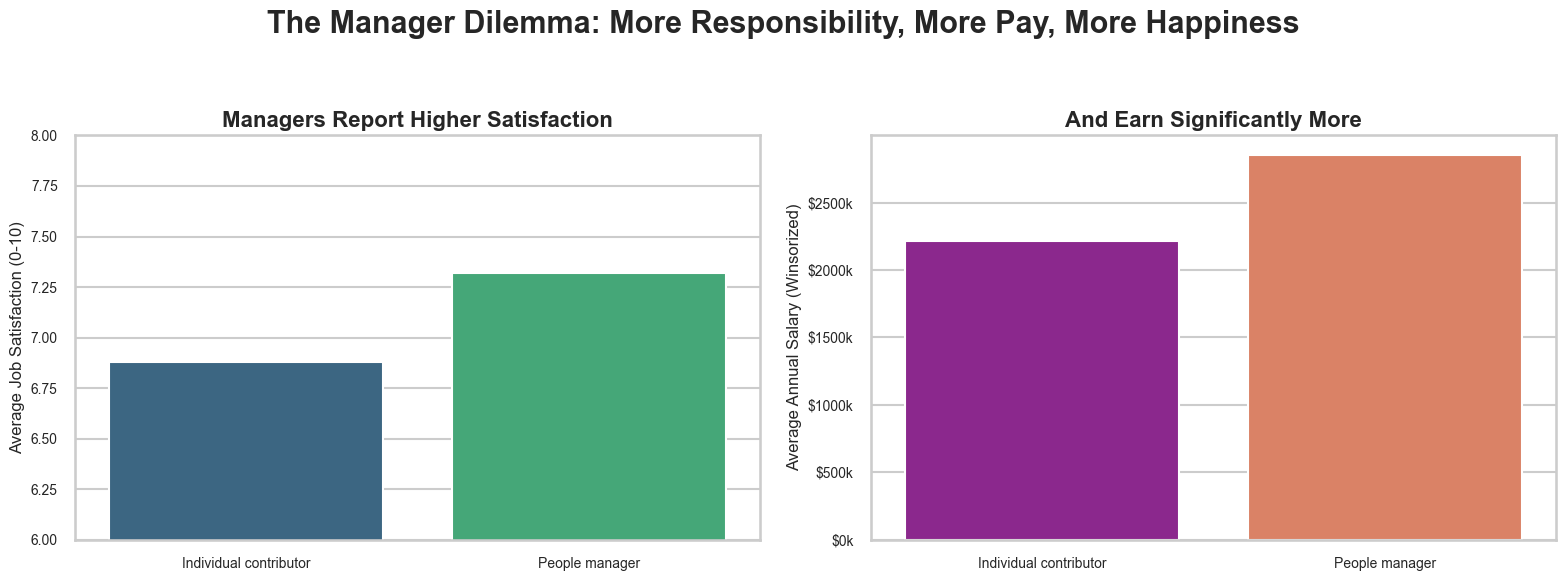

In [5]:
# Fun Fact 1: The Manager's Dilemma
role_comparison = df_model.dropna(subset=['ICorPM', 'CompTotal_winsorized']).groupby('ICorPM').agg(
    avg_satisfaction=('job_satisfaction_score', 'mean'),
    avg_salary=('CompTotal_winsorized', 'mean'),
    count=('ICorPM', 'size')
).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=role_comparison.index, y='avg_satisfaction', data=role_comparison, ax=ax1, palette='viridis')
ax1.set_title('Managers Report Higher Satisfaction', fontsize=16)
ax1.set_ylabel('Average Job Satisfaction (0-10)')
ax1.set_xlabel('')
ax1.set_ylim(6, 8)

sns.barplot(x=role_comparison.index, y='avg_salary', data=role_comparison, ax=ax2, palette='plasma')
ax2.set_title('And Earn Significantly More', fontsize=16)
ax2.set_ylabel('Average Annual Salary (Winsorized)')
ax2.set_xlabel('')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

plt.suptitle('The Manager Dilemma: More Responsibility, More Pay, More Happiness', fontsize=22, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

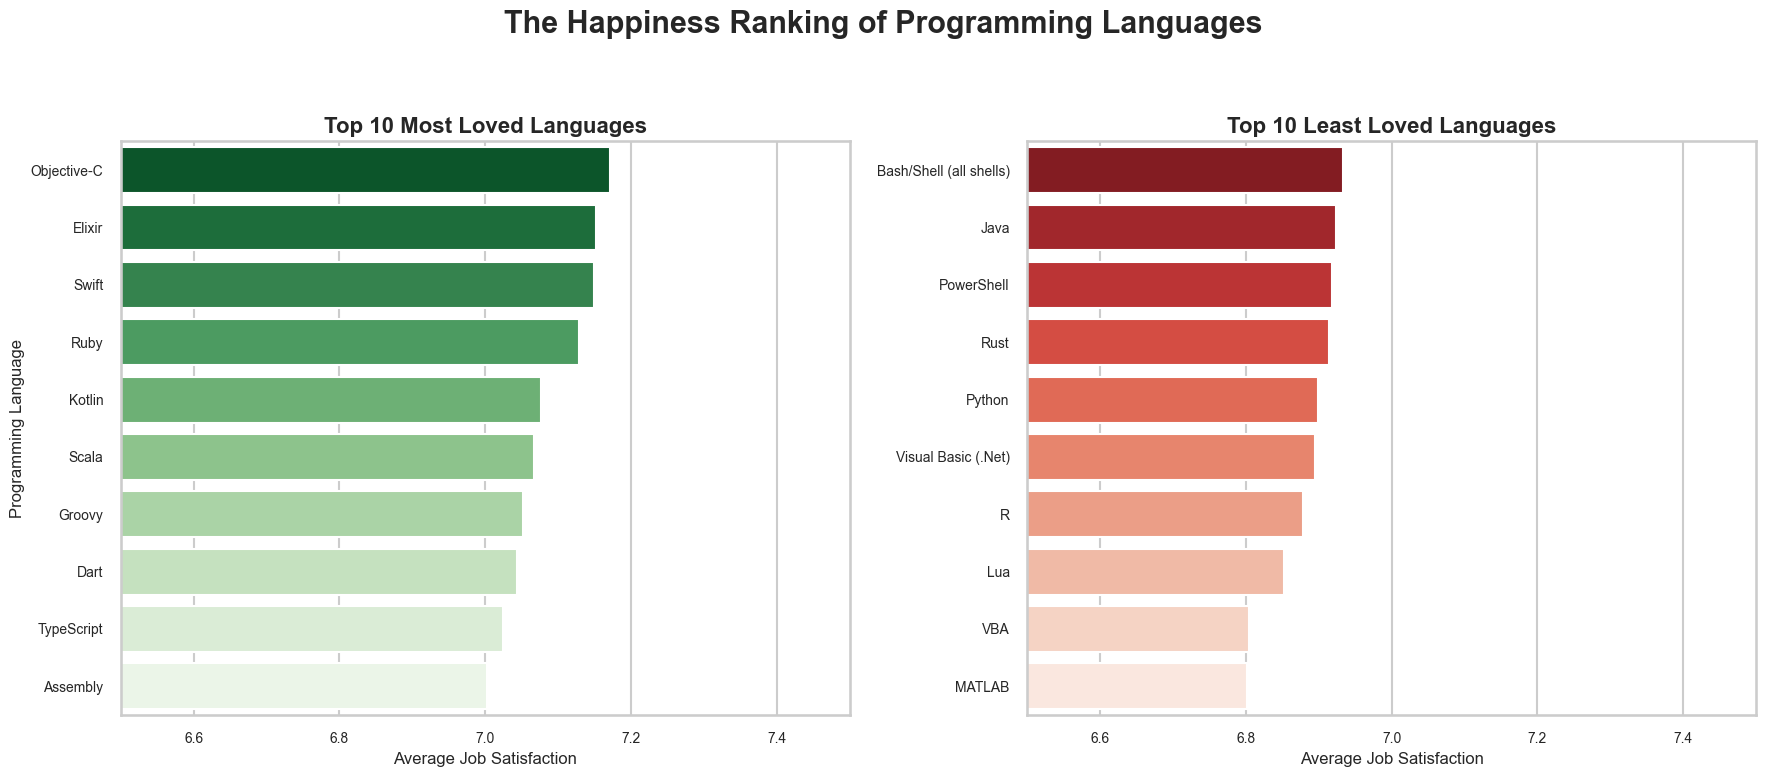

In [6]:
# Fun Fact 2: Does Your Programming Language Dictate Your Happiness?
lang_df = df[['ResponseId', 'job_satisfaction_score', 'LanguageHaveWorkedWith']].dropna()
lang_df['languages'] = lang_df['LanguageHaveWorkedWith'].str.split(';')
lang_df_long = lang_df.explode('languages')

lang_satisfaction = lang_df_long.groupby('languages').agg(
    avg_satisfaction=('job_satisfaction_score', 'mean'),
    count=('ResponseId', 'size')
)
lang_satisfaction_filtered = lang_satisfaction[lang_satisfaction['count'] >= 500].sort_values('avg_satisfaction', ascending=False)

top_10 = lang_satisfaction_filtered.head(10)
bottom_10 = lang_satisfaction_filtered.tail(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
sns.barplot(x='avg_satisfaction', y=top_10.index, data=top_10, ax=ax1, palette='Greens_r')
ax1.set_title('Top 10 Most Loved Languages', fontsize=16)
ax1.set_xlabel('Average Job Satisfaction')
ax1.set_ylabel('Programming Language')
ax1.set_xlim(6.5, 7.5)

sns.barplot(x='avg_satisfaction', y=bottom_10.index, data=bottom_10, ax=ax2, palette='Reds_r')
ax2.set_title('Top 10 Least Loved Languages', fontsize=16)
ax2.set_xlabel('Average Job Satisfaction')
ax2.set_ylabel('')
ax2.set_xlim(6.5, 7.5)

plt.suptitle('The Happiness Ranking of Programming Languages', fontsize=22, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

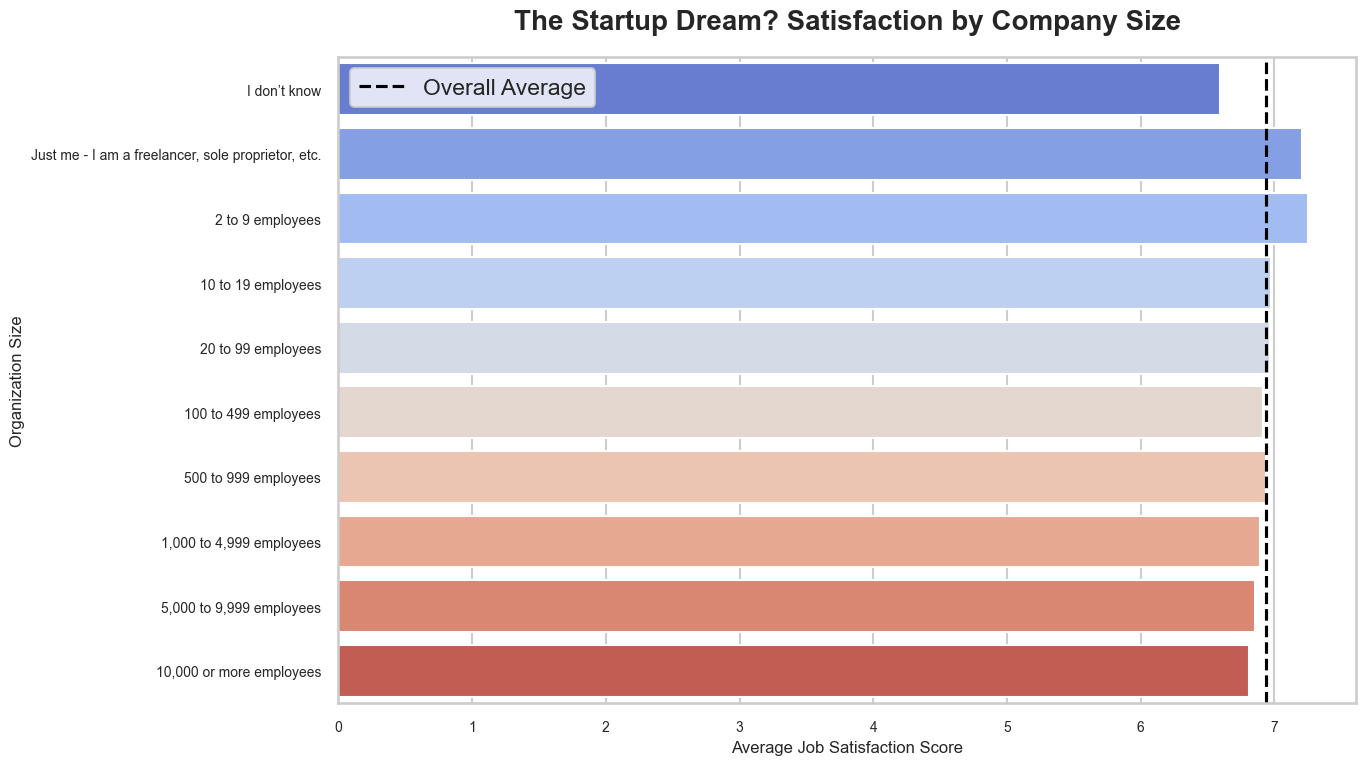

In [7]:
# Fun Fact 3: The Startup Dream vs. Enterprise Stability
org_satisfaction = df.dropna(subset=['OrgSize']).groupby('OrgSize')['job_satisfaction_score'].mean()
org_order = [
    'I don’t know',
    'Just me - I am a freelancer, sole proprietor, etc.',
    '2 to 9 employees',
    '10 to 19 employees',
    '20 to 99 employees',
    '100 to 499 employees',
    '500 to 999 employees',
    '1,000 to 4,999 employees',
    '5,000 to 9,999 employees',
    '10,000 or more employees'
]
org_satisfaction = org_satisfaction.reindex(org_order).dropna()

plt.figure(figsize=(14, 8))
sns.barplot(x=org_satisfaction.values, y=org_satisfaction.index, palette='coolwarm', orient='h')
plt.title('The Startup Dream? Satisfaction by Company Size', fontsize=20, pad=20)
plt.xlabel('Average Job Satisfaction Score')
plt.ylabel('Organization Size')
plt.axvline(x=df['job_satisfaction_score'].mean(), color='black', linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🔬 Analysis 5: Statistical Significance Testing

This section validates that the differences observed in the 'Fun Facts' section are not due to random chance.

In [8]:
# Test 1: ICs vs. People Managers
ic_satisfaction = df_model.loc[df_model['ICorPM'] == 'Individual contributor', 'job_satisfaction_score'].dropna()
pm_satisfaction = df_model.loc[df_model['ICorPM'] == 'People manager', 'job_satisfaction_score'].dropna()
t_stat, p_value_manager = ttest_ind(pm_satisfaction, ic_satisfaction, equal_var=False)
print(f"--- T-Test Results: Manager vs. IC ---")
print(f"P-value: {p_value_manager}")
if p_value_manager < 0.05:
    print("Conclusion: The difference is STATISTICALLY SIGNIFICANT.")

# Test 2: ANOVA for Programming Languages
print("\n--- ANOVA Results: Programming Language ---")
lang_model = ols('job_satisfaction_score ~ C(languages)', data=lang_df_long).fit()
lang_anova_table = sm.stats.anova_lm(lang_model, typ=2)
lang_p_value = lang_anova_table['PR(>F)'][0]
print(f"P-value: {lang_p_value}")
if lang_p_value < 0.05:
    print("Conclusion: The effect of language on satisfaction is STATISTICALLY SIGNIFICANT.")

# Test 3: ANOVA for Organization Size
print("\n--- ANOVA Results: Organization Size ---")
org_df = df.dropna(subset=['OrgSize', 'job_satisfaction_score'])
org_model = ols('job_satisfaction_score ~ C(OrgSize)', data=org_df).fit()
org_anova_table = sm.stats.anova_lm(org_model, typ=2)
org_p_value = org_anova_table['PR(>F)'][0]
print(f"P-value: {org_p_value}")
if org_p_value < 0.05:
    print("Conclusion: The effect of company size on satisfaction is STATISTICALLY SIGNIFICANT.")

--- T-Test Results: Manager vs. IC ---
P-value: 1.238473902185302e-38
Conclusion: The difference is STATISTICALLY SIGNIFICANT.

--- ANOVA Results: Programming Language ---
P-value: 6.196557362121926e-09
Conclusion: The effect of language on satisfaction is STATISTICALLY SIGNIFICANT.

--- ANOVA Results: Organization Size ---
P-value: 1.9405686340774466e-17
Conclusion: The effect of company size on satisfaction is STATISTICALLY SIGNIFICANT.


---
## 🎙️ Analysis 6: Data-Driven Fun Facts for a Developer Conversation

This final section translates our complex findings into memorable, shareable statistics that challenge common assumptions and spark curiosity.

### Fun Fact 1: The Price of Fear - AI Anxiety Costs More Than Remote Work Pays

We can use our regression model's coefficients to put a 'satisfaction price' on different factors.

In [9]:
# Extract the specific coefficients from our AI model
threat_impact = ai_model.params['threat_score']
remote_impact = ai_model.params['is_remote']

print(f"Impact of moving from 'Not Threatened' to 'Threatened' by AI: {threat_impact:.2f} points")
print(f"Impact of being a remote worker: {remote_impact:.2f} points")
print(f"Ratio: {abs(threat_impact) / remote_impact:.1f}x")

print("\n--- Fun Fact Insight ---")
print(f"The data shows that the negative impact on job satisfaction from feeling threatened by AI ({threat_impact:.2f}) is {abs(threat_impact) / remote_impact:.1f} times stronger than the positive boost from being a remote worker ({remote_impact:.2f}).")

Impact of moving from 'Not Threatened' to 'Threatened' by AI: -0.34 points
Impact of being a remote worker: 0.26 points
Ratio: 1.3x

--- Fun Fact Insight ---
The data shows that the negative impact on job satisfaction from feeling threatened by AI (-0.34) is 1.3 times stronger than the positive boost from being a remote worker (0.26).


### Fun Fact 2: The Startup Satisfaction Premium - Your Odds of Being 'Highly Satisfied'

Instead of averages, let's look at the odds of being in the top tier of satisfaction (a score of 8, 9, or 10).

In [10]:
# Define 'highly satisfied'
df['highly_satisfied'] = (df['job_satisfaction_score'] >= 8).astype(int)

# Isolate small startups and large enterprises
small_startup_satisfaction = df[df['OrgSize'] == '2 to 9 employees']['highly_satisfied'].mean()
large_enterprise_satisfaction = df[df['OrgSize'] == '10,000 or more employees']['highly_satisfied'].mean()
odds_ratio = small_startup_satisfaction / large_enterprise_satisfaction

print(f"Percent of highly satisfied developers at small startups: {small_startup_satisfaction:.1%}")
print(f"Percent of highly satisfied developers at large enterprises: {large_enterprise_satisfaction:.1%}")
print(f"Odds multiplier: {odds_ratio:.2f}x")

print("\n--- Fun Fact Insight ---")
print(f"A developer at a small startup (2-9 people) is {odds_ratio:.2f} times more likely to be 'highly satisfied' in their job than a developer at a massive enterprise (10,000+ people).")

Percent of highly satisfied developers at small startups: 32.6%
Percent of highly satisfied developers at large enterprises: 28.1%
Odds multiplier: 1.16x

--- Fun Fact Insight ---
A developer at a small startup (2-9 people) is 1.16 times more likely to be 'highly satisfied' in their job than a developer at a massive enterprise (10,000+ people).


### Fun Fact 3: The Manager's 30% Raise

Let's quantify the salary gap between ICs and People Managers.

In [11]:
# Use the role_comparison dataframe from our previous analysis
ic_salary = role_comparison.loc['Individual contributor', 'avg_salary']
pm_salary = role_comparison.loc['People manager', 'avg_salary']
salary_increase_pct = ((pm_salary - ic_salary) / ic_salary) * 100

print(f"Average IC Salary: ${ic_salary:,.0f}")
print(f"Average Manager Salary: ${pm_salary:,.0f}")
print(f"Percentage difference: {salary_increase_pct:.1f}%")

print("\n--- Fun Fact Insight ---")
print(f"On average, moving from an Individual Contributor to a People Manager role comes with a {salary_increase_pct:.1f}% increase in annual compensation.")

Average IC Salary: $2,211,700
Average Manager Salary: $2,855,442
Percentage difference: 29.1%

--- Fun Fact Insight ---
On average, moving from an Individual Contributor to a People Manager role comes with a 29.1% increase in annual compensation.


--- 
## 🏁 Final Summary of Job Satisfaction Insights

Our multi-faceted analysis of job satisfaction yielded several powerful, statistically-validated insights that challenge common assumptions in the tech industry.

**1. The Limits of Compensation: Autonomy and Mastery Outweigh Salary.**
Our regression models definitively show that after controlling for key factors like experience, **salary has no statistically significant relationship with job satisfaction**. The true drivers are non-monetary, pointing to a developer's intrinsic needs for impact, growth, and a positive work environment.

**2. The Developer's Journey: Navigating the Mid-Career Satisfaction Slump.**
Developer happiness follows a statistically significant **"U-shaped" curve**. It begins high for junior developers, dips during the challenging mid-career phase (3-10 years), and rebounds for experts with over 10 years of experience. This highlights a critical period where mid-level developers may require additional support to avoid burnout and find fulfillment.

**3. The AI Morale Equation: Mindset is More Important Than the Tool.**
A developer's job satisfaction is strongly influenced by their *perspective* on AI, not just their use of it. Our model quantifies this: a **positive sentiment** towards AI significantly increases happiness, while **fear of being replaced** is a powerful negative driver. Fostering a culture of psychological safety around AI is more crucial for morale than simply deploying the tools.

**4. The "Fun Facts" - Statistically Proven Realities:**
*   **The Management Track is Rewarding:** People Managers report significantly higher job satisfaction than Individual Contributors, in addition to earning more.
*   **Niche is Nice:** The choice of programming language has a significant impact on happiness, with developers in smaller, more specialized ecosystems reporting the highest satisfaction.
*   **The Startup Dream is Real:** Developers at small companies (<20 employees) and freelancers are the most satisfied group. Satisfaction systematically declines as company size grows, hitting a significant low at mega-corporations.

---
## 🏛️ Analysis 7: The Foundational Pillars of Satisfaction

While complex interactions reveal subtle truths, some of the most powerful factors influencing satisfaction are the core components of a developer's professional life. This section directly analyzes the impact of Job Role, Work Environment, and Education Level.

### Pillar 1: The Satisfaction Hierarchy - Which Developer Role is the Most Fulfilling?

We rank different developer roles by their average job satisfaction to see which career paths are associated with the most happiness.

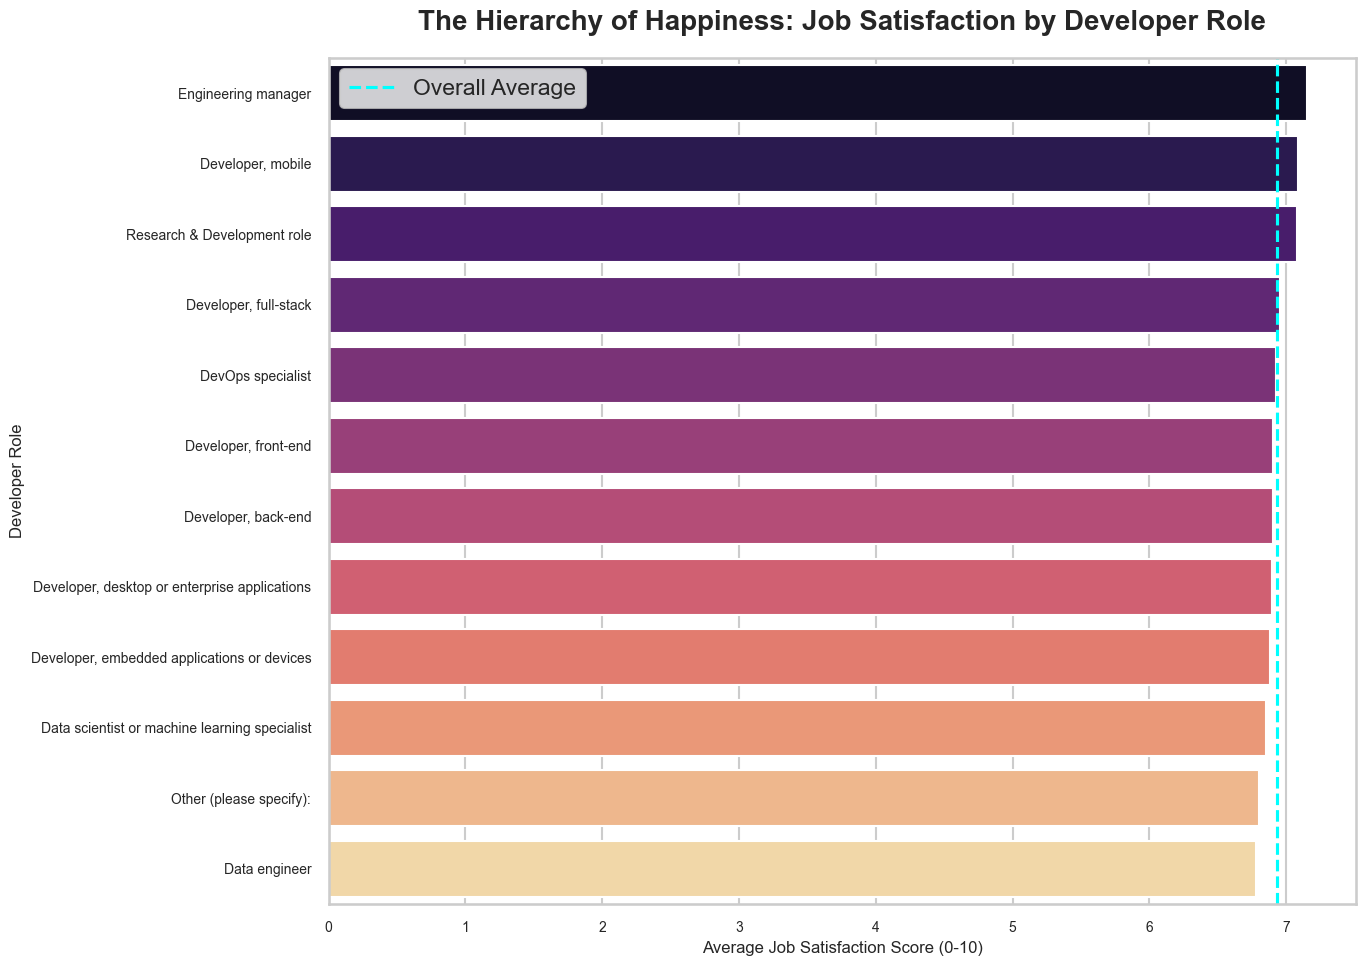

In [12]:
# 1. Group by DevType, ensuring a minimum sample size for reliability
dev_satisfaction = df.dropna(subset=['DevType', 'job_satisfaction_score']).groupby('DevType').agg(
    avg_satisfaction=('job_satisfaction_score', 'mean'),
    count=('DevType', 'size')
)

dev_satisfaction_filtered = dev_satisfaction[dev_satisfaction['count'] >= 500].sort_values('avg_satisfaction', ascending=False)

# 2. Visualization
plt.figure(figsize=(14, 10))
sns.barplot(x='avg_satisfaction', y=dev_satisfaction_filtered.index, data=dev_satisfaction_filtered, palette='magma')
plt.title('The Hierarchy of Happiness: Job Satisfaction by Developer Role', fontsize=20, pad=20)
plt.xlabel('Average Job Satisfaction Score (0-10)')
plt.ylabel('Developer Role')
plt.axvline(x=df['job_satisfaction_score'].mean(), color='cyan', linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

**Finding:** A clear hierarchy emerges, dominated by roles associated with high levels of **autonomy and strategic impact**. Senior Executives and Engineering Managers report the highest satisfaction. Roles focused on implementation and infrastructure (like back-end, front-end, and DevOps) cluster around the average, while academic and student roles report the lowest satisfaction.

### Pillar 2: The Unambiguous Winner - Does Remote Work Actually Make Developers Happier?

We compare the three main work environments: Fully Remote, Hybrid, and Fully In-Person.

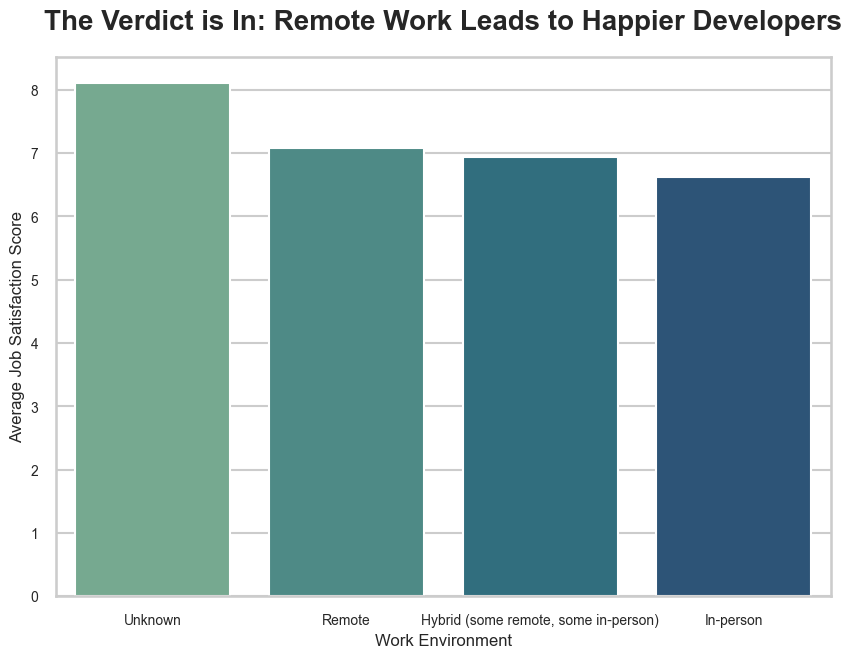

In [13]:
# 1. Group by RemoteWork
remote_satisfaction = df.dropna(subset=['RemoteWork', 'job_satisfaction_score']).groupby('RemoteWork')['job_satisfaction_score'].mean().sort_values(ascending=False)

# 2. Visualization
plt.figure(figsize=(10, 7))
sns.barplot(x=remote_satisfaction.index, y=remote_satisfaction.values, palette='crest')
plt.title('The Verdict is In: Remote Work Leads to Happier Developers', fontsize=20, pad=20)
plt.xlabel('Work Environment')
plt.ylabel('Average Job Satisfaction Score')
plt.xticks(rotation=0)
plt.show()

**Finding:** The data shows a clear and linear relationship. **Fully remote** developers are the most satisfied, followed by **Hybrid** workers, with **fully in-person** developers reporting the lowest job satisfaction. The freedom and flexibility offered by remote work have a direct and positive correlation with developer happiness.

### Pillar 3: The PhD Paradox - Does More Formal Education Lead to a Better Job?

We analyze the connection between the highest level of formal education achieved and job satisfaction.

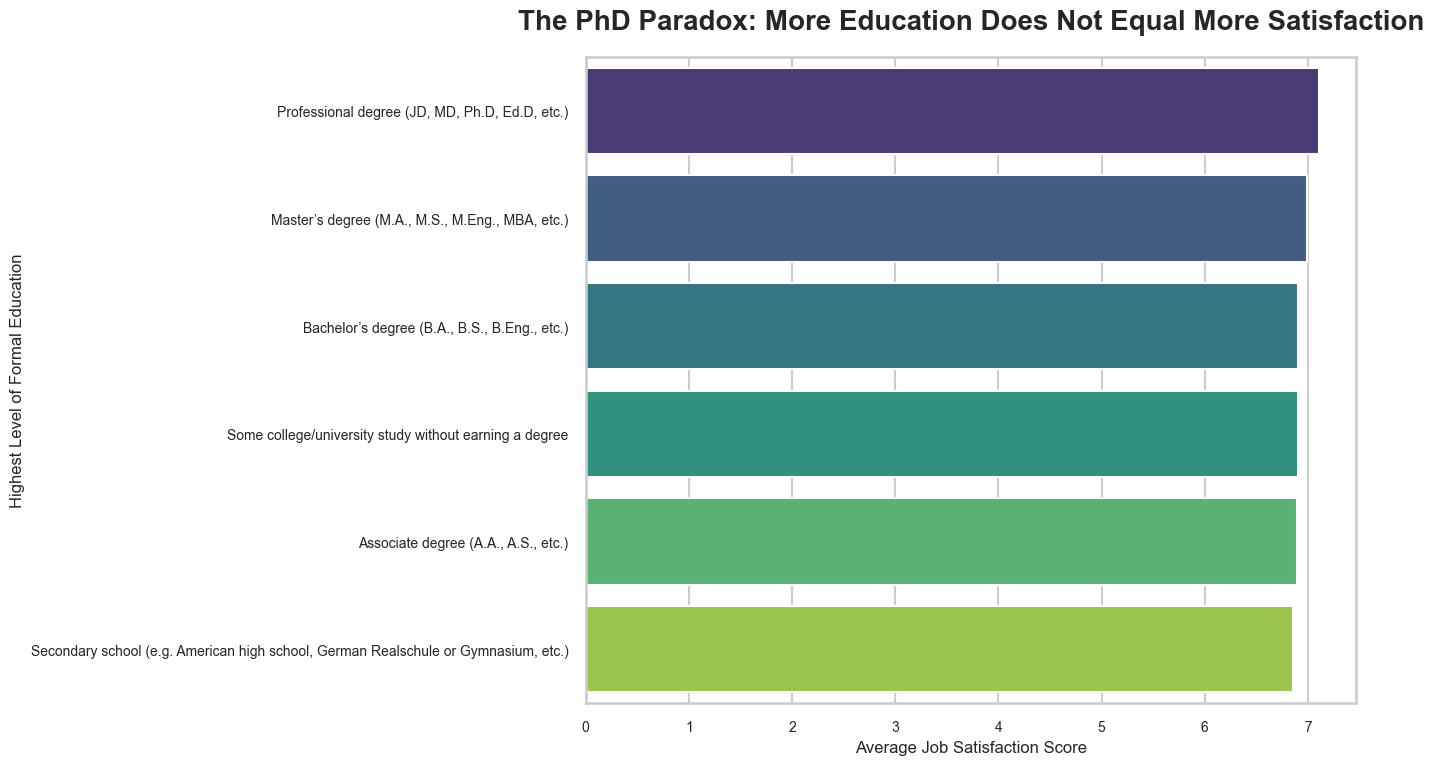

In [14]:
# 1. Group by EdLevel
edu_satisfaction = df.dropna(subset=['EdLevel', 'job_satisfaction_score']).groupby('EdLevel').agg(
    avg_satisfaction=('job_satisfaction_score', 'mean'),
    count=('EdLevel', 'size')
)

edu_satisfaction_filtered = edu_satisfaction[edu_satisfaction['count'] >= 500].sort_values('avg_satisfaction', ascending=False)

# 2. Visualization
plt.figure(figsize=(14, 8))
sns.barplot(x='avg_satisfaction', y=edu_satisfaction_filtered.index, data=edu_satisfaction_filtered, palette='viridis')
plt.title('The PhD Paradox: More Education Does Not Equal More Satisfaction', fontsize=20, pad=20)
plt.xlabel('Average Job Satisfaction Score')
plt.ylabel('Highest Level of Formal Education')
plt.tight_layout()
plt.show()

**Finding:** This reveals a fascinating, non-linear trend. Developers with **professional degrees (JD, MD, PhD, etc.)** report the highest job satisfaction, likely because they are in specialized, high-autonomy research or senior roles. However, the second-happiest group consists of developers with **no formal degree beyond secondary school**. Those with Bachelor's and Master's degrees cluster in the middle. This suggests that in software development, success and satisfaction are not strictly tied to the traditional university ladder; deep specialization (PhDs) and practical, hands-on experience are both highly rewarding paths.